# Smart FAQ Retrieval — Project Walkthrough

This notebook walks through the **Smart-FAQ-Minimal** project step by step:
how a raw question typed by a user turns into an answer from the 215-question
KUET FAQ dataset.

**Pipeline**

```
User question
     |
Spelling correction   (Lab 1 — edit distance)
     |
Text preprocessing    (Lab 1 — cleaning, stop words, stemming)
     |
     +----------------+------------------------------+----------------+
     |                |                               |                |
  TF-IDF           Word2Vec              Word2Vec (TF-IDF weighted)  Sentence-BERT
  (Lab 2)           (Lab 3)                      (Lab 3)              (Phase 5)
     |                |                               |                |
     +----------------+------------------------------+----------------+
                       |
              Cosine similarity + threshold
                       |
                Top-3 FAQ matches
```

Sentence-BERT is the odd one out in that diagram: it is a **pretrained**
transformer, so it skips the "text preprocessing" box entirely and encodes
the raw question directly (see Section 4).

Every function used below lives in `preprocessing.py` and `retrieval.py` in
this same folder — this notebook imports and calls the real project code, it
does not re-implement it.


## 1. Setup

Load the FAQ dataset and take a first look at it. Every FAQ has a
`source` (the official KUET page it came from) and a `last_verified` date
(20 September 2026), which the app shows before each answer.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from preprocessing import preprocess, tokenize, edit_distance, spell_correct, load_english_words
from retrieval import build_system, search, MODELS, THRESHOLDS

pd.set_option("display.max_colwidth", 100)

faq_df = pd.read_csv("data/faq.csv")
print("Rows:", len(faq_df))
faq_df.head()


Rows: 215


,id,question,answer,category,source,source_type,last_verified
0,1,When was KUET founded?,KUET began as Khulna Engineering College in 1967. Academic activities started on 3 June 1974.,university_information,https://www.kuet.ac.bd/about-kuet/history,official_web,2026-09-20
1,2,Which departments did KUET have when academic activities began?,"Academic activities began with the Civil Engineering, Electrical and Electronic Engineering, and...",university_information,https://www.kuet.ac.bd/about-kuet/history,official_web,2026-09-20
2,3,When did Khulna Engineering College become BIT Khulna?,It was converted into Bangladesh Institute of Technology Khulna on 1 July 1986.,university_information,https://www.kuet.ac.bd/about-kuet/history,official_web,2026-09-20
3,4,When did the institution become KUET?,The institute became Khulna University of Engineering & Technology on 1 September 2003.,university_information,https://www.kuet.ac.bd/about-kuet/history,official_web,2026-09-20
4,5,What type of university is KUET?,KUET is a public engineering university in Bangladesh.,university_information,https://www.kuet.ac.bd/about-kuet/kuetataglance,official_web,2026-09-20


In [2]:
faq_df["category"].value_counts().head(8)


category
cse_information           25
library                   23
department_overviews      20
university_information    18
undergraduate_programs    18
residential_halls         12
department_history        12
academic_services         11
Name: count, dtype: int64

## 2. Text Preprocessing (Lab 1)

`preprocess()` lowercases the text, strips punctuation, and collapses extra
spaces. `tokenize(text, clean=True)` goes further: it removes stop words
(*"the"*, *"is"*, *"does"* …) and stems each remaining word with the Porter
stemmer, so *"books"* and *"book"* become the same token. Question words like
*what/when/where/who* are deliberately **kept** — dropping them would make
"When was KUET founded?" look identical to "Where is KUET?".


In [3]:
examples = [
    "How many books may a KUET undergraduate borrow?",
    "Does KUET provide institutional email?",
]

for text in examples:
    print("original :", text)
    print("basic    :", preprocess(text))
    print("clean    :", " ".join(tokenize(text, clean=True)))
    print()


original : How many books may a KUET undergraduate borrow?
basic    : how many books may a kuet undergraduate borrow
clean    : how mani book undergradu borrow

original : Does KUET provide institutional email?
basic    : does kuet provide institutional email
clean    : provid institut email



## 3. Spelling Correction (Lab 1 — Edit Distance)

`edit_distance(a, b)` is the classic Levenshtein distance: the minimum number
of insertions, deletions, and substitutions to turn word `a` into word `b`.


In [4]:
pairs = [("admisson", "admission"), ("kitten", "sitting"), ("libary", "library")]
for a, b in pairs:
    print(f"edit_distance({a!r}, {b!r}) = {edit_distance(a, b)}")


edit_distance('admisson', 'admission') = 1
edit_distance('kitten', 'sitting') = 3
edit_distance('libary', 'library') = 1


`spell_correct()` uses this distance to fix typos, but only for words that are
**not** already valid English words (checked against NLTK's word list) and not
already in the FAQ vocabulary. This stops it from "fixing" real words like
*cook* into an unrelated FAQ word like *book*.


In [5]:
faq_vocabulary = set()
for text in list(faq_df["question"]) + list(faq_df["answer"]):
    faq_vocabulary.update(tokenize(text))

english_words = load_english_words()
print("FAQ vocabulary size:", len(faq_vocabulary))
print("English word list loaded:", len(english_words) > 0, f"({len(english_words)} words)")

typo_queries = [
    "admisson circuler for undergraduate",
    "libary overdue fine",
    "when was kuet fonded",
    "does kuet have a gymnasiam",
]

for query in typo_queries:
    corrected, changes = spell_correct(query, faq_vocabulary, english_words)
    print(f"{query!r}\n  -> {corrected!r}   changes: {changes}\n")


FAQ vocabulary size: 1054
English word list loaded: True (234377 words)
'admisson circuler for undergraduate'
  -> 'admission circular for undergraduate'   changes: [('admisson', 'admission'), ('circuler', 'circular')]

'libary overdue fine'
  -> 'library overdue fine'   changes: [('libary', 'library')]

'when was kuet fonded'
  -> 'when was kuet founded'   changes: [('fonded', 'founded')]

'does kuet have a gymnasiam'
  -> 'does kuet have a gymnasium'   changes: [('gymnasiam', 'gymnasium')]



## 4. Building All Four Retrieval Models

`build_system()` builds everything once: the TF-IDF vectorizer, the Word2Vec
model, the TF-IDF-weighted Word2Vec vectors, and the Sentence-BERT
embeddings — the first three share the same preprocessing setting
(`clean=True` turns on stop-word removal + stemming from Section 2).
Sentence-BERT ignores that setting: it is a pretrained transformer, not
something trained on the FAQ text, so it always reads the raw question.


In [6]:
system = build_system(faq_df, clean=True)

print("TF-IDF vocabulary size:", len(system["vectorizer"].get_feature_names_out()))
print("Word2Vec vector size  :", system["word2vec"].vector_size)
print("Word2Vec vocabulary   :", len(system["word2vec"].wv))
print("Sentence-BERT loaded  :", system["sbert"] is not None)
if system["sbert"] is not None:
    print("Sentence-BERT vector size:", system["sbert_vectors"].shape[1])


D:\4.1\NLP\lab\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3029.31it/s]

TF-IDF vocabulary size: 334
Word2Vec vector size  : 100
Word2Vec vocabulary   : 822
Sentence-BERT loaded  : True
Sentence-BERT vector size: 384


### TF-IDF (Lab 2)

Each FAQ question becomes a vector of word importance scores (rare words that
still appear in a question score higher than common words). A query is
compared against every FAQ question with cosine similarity.


In [7]:
sample_query = "How many books can an undergraduate student borrow?"

results, threshold, _ = search("TF-IDF", sample_query, system)
print(f"Threshold: {threshold}\n")
for rank, r in enumerate(results, start=1):
    print(f"{rank}. [{r['similarity']:.2%}] {r['question']}")


Threshold: 0.56

1. [90.13%] How many books may a KUET undergraduate borrow?
2. [78.83%] How many books may a KUET master's student borrow?
3. [50.01%] How many students are enrolled at KUET?


### Word2Vec (Lab 3)

Word2Vec learns a dense vector for every word from the FAQ text itself, so
that words used in similar contexts end up with similar vectors. A sentence is
represented by **averaging** the vectors of its words.


In [8]:
# Words the model has learned to associate with "library"
system["word2vec"].wv.most_similar("librari", topn=5)  # "library" -> stemmed to "librari"


[('lost', 0.5723892450332642),
 ('replac', 0.5665953159332275),
 ('sejuti', 0.5342428088188171),
 ('if', 0.5258859992027283),
 ('thousand', 0.5244328379631042)]

In [9]:
results, threshold, _ = search("Word2Vec", sample_query, system)
print(f"Threshold: {threshold}\n")
for rank, r in enumerate(results, start=1):
    print(f"{rank}. [{r['similarity']:.2%}] {r['question']}")


Threshold: 0.87

1. [96.83%] How many books may a KUET undergraduate borrow?
2. [94.66%] How many books may a KUET master's student borrow?
3. [87.53%] How many students are enrolled at KUET?


### Word2Vec, TF-IDF weighted (Lab 3 extension)

Plain averaging lets common words like *"does"* or *"many"* pull the sentence
vector away from the words that actually matter. This version weights each
word's vector by its TF-IDF score before averaging, so rare, informative words
(*"library"*, *"scholarship"*) count more than common ones.


In [10]:
results, threshold, _ = search("Word2Vec (TF-IDF weighted)", sample_query, system)
print(f"Threshold: {threshold}\n")
for rank, r in enumerate(results, start=1):
    print(f"{rank}. [{r['similarity']:.2%}] {r['question']}")


Threshold: 0.79

1. [96.44%] How many books may a KUET undergraduate borrow?
2. [93.56%] How many books may a KUET master's student borrow?
3. [86.68%] How many students are enrolled at KUET?


### Sentence-BERT (Phase 5)

Sentence-BERT (`all-MiniLM-L6-v2`) is a **pretrained** transformer: unlike the other three models, it is not trained on this FAQ dataset at all — it already knows English from a much larger corpus it saw during pretraining. It reads the **raw** question, with no stop-word removal or stemming, because it needs word order and grammar to understand meaning, and it encodes the whole sentence directly into a single vector (no averaging of word vectors, unlike Word2Vec above).


In [11]:
results, threshold, _ = search("Sentence-BERT", sample_query, system)
print(f"Threshold: {threshold}\n")
for rank, r in enumerate(results, start=1):
    print(f"{rank}. [{r['similarity']:.2%}] {r['question']}")


Threshold: 0.4

1. [85.34%] How many books may a KUET undergraduate borrow?
2. [77.38%] How many books may a KUET master's student borrow?
3. [60.43%] What may a KUET PhD student borrow from the library?


## 5. Side-by-Side Comparison

The same set of queries — a clean question, a typo, and a paraphrase — run through all four models at once, with spelling correction switched on.


In [12]:
demo_queries = [
    "When was KUET founded?",
    "admisson circuler for undergraduate",
    "Is it possible to extend my borrowed book's due date through the internet?",
]

rows = []
for query in demo_queries:
    for model_name in MODELS:
        results, threshold, changes = search(model_name, query, system, correct_spelling=True)
        best = results[0] if results else None
        rows.append({
            "query": query,
            "model": model_name,
            "top_answer": best["question"] if best else "(no match)",
            "similarity": f"{best['similarity']:.2%}" if best else "-",
            "passes_threshold": bool(best and best["similarity"] >= threshold),
        })

pd.DataFrame(rows)


,query,model,top_answer,similarity,passes_threshold
0,When was KUET founded?,TF-IDF,When was KUET founded?,100.00%,True
1,When was KUET founded?,Word2Vec,When was KUET founded?,100.00%,True
2,When was KUET founded?,Word2Vec (TF-IDF weighted),When was KUET founded?,100.00%,True
3,When was KUET founded?,Sentence-BERT,When was KUET founded?,95.42%,True
4,admisson circuler for undergraduate,TF-IDF,Where can I find the KUET undergraduate admission circular?,79.78%,True
5,admisson circuler for undergraduate,Word2Vec,Where can I find the KUET undergraduate admission circular?,88.34%,True
6,admisson circuler for undergraduate,Word2Vec (TF-IDF weighted),Where can I find the KUET undergraduate admission circular?,89.81%,True
7,admisson circuler for undergraduate,Sentence-BERT,Where can I find the KUET undergraduate admission circular?,66.12%,True
8,Is it possible to extend my borrowed book's due date through the internet?,TF-IDF,Does the KUET library send due-date notices?,48.09%,False
9,Is it possible to extend my borrowed book's due date through the internet?,Word2Vec,Does the KUET library send due-date notices?,78.05%,False


## 6. Evaluation on the Development Set

`data/dev_queries.csv` has 53 in-scope questions (paraphrased or with typos —
none copied word-for-word from the FAQ) and 8 out-of-scope questions that
should be **rejected**. This is the **development set**: the thresholds in
`retrieval.py` were tuned on it, so its scores are optimistic. The honest
final number comes from the held-out test in Section 7.


In [13]:
dev = pd.read_csv("data/dev_queries.csv")
print(f"{len(dev)} development queries: "
      f"{(dev['type'] != 'out_of_scope').sum()} in-scope, "
      f"{(dev['type'] == 'out_of_scope').sum()} out-of-scope")
dev.head()


61 development queries: 53 in-scope, 8 out-of-scope


,query,expected_id,type
0,What year was the university established?,1.0,paraphrase
1,Count of academic faculties at this university,6.0,paraphrase
2,What is the area of the campus in acres?,9.0,paraphrase
3,How many years does it take to finish a BSc in engineering?,14.0,paraphrase
4,Book borrowing limit for bachelor students,50.0,paraphrase


In [14]:
def evaluate_model(model_name, system, queries, correct_spelling=True):
    rows = []
    for test in queries.itertuples():
        results, threshold, _ = search(model_name, test.query, system, correct_spelling)
        ids = [r["id"] for r in results]
        in_scope = test.type != "out_of_scope"
        expected = int(test.expected_id) if in_scope else None
        rows.append({
            "in_scope": in_scope,
            "top1": bool(ids) and ids[0] == expected,
            "top3": expected in ids,
            "score": results[0]["similarity"] if results else 0.0,
            "threshold": threshold,
        })

    scoped = [r for r in rows if r["in_scope"]]
    oos = [r for r in rows if not r["in_scope"]]
    return {
        "Top-1 accuracy": np.mean([r["top1"] for r in scoped]),
        "Top-3 accuracy": np.mean([r["top3"] for r in scoped]),
        "Out-of-scope rejected": np.mean([r["score"] < r["threshold"] for r in oos]),
    }


summary = pd.DataFrame({model: evaluate_model(model, system, dev) for model in MODELS}).T
summary


,Top-1 accuracy,Top-3 accuracy,Out-of-scope rejected
TF-IDF,0.415094,0.528302,0.875
Word2Vec,0.471698,0.566038,0.750
Word2Vec (TF-IDF weighted),0.433962,0.641509,0.750
Sentence-BERT,0.792453,0.905660,1.000


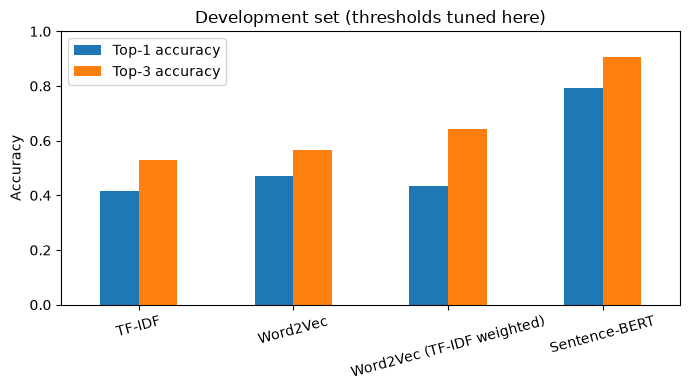

In [15]:
ax = summary[["Top-1 accuracy", "Top-3 accuracy"]].plot(
    kind="bar", figsize=(7, 4), rot=15, ylim=(0, 1)
)
ax.set_ylabel("Accuracy")
ax.set_title("Development set (thresholds tuned here)")
plt.tight_layout()
plt.show()


## 7. Held-Out Final Test

`data/final_test_queries.csv` has 20 new queries (12 paraphrases, 3 typos,
5 out-of-scope) written **after** the thresholds were tuned and never used
to change anything. Thresholds stay frozen, so this is the honest result.
Two of the out-of-scope queries are deliberately close to the FAQ's domain
(another university's admission fee, applying for a visa).


In [16]:
final_test = pd.read_csv("data/final_test_queries.csv")
final_summary = pd.DataFrame(
    {model: evaluate_model(model, system, final_test) for model in MODELS}
).T
final_summary


,Top-1 accuracy,Top-3 accuracy,Out-of-scope rejected
TF-IDF,0.533333,0.666667,1.0
Word2Vec,0.333333,0.533333,1.0
Word2Vec (TF-IDF weighted),0.400000,0.600000,0.6
Sentence-BERT,0.933333,0.933333,0.6


In [17]:
# Which out-of-scope queries does each model wrongly answer?
oos_queries = final_test[final_test["type"] == "out_of_scope"]["query"]
rows = []
for query in oos_queries:
    row = {"query": query}
    for model_name in MODELS:
        results, threshold, _ = search(model_name, query, system, correct_spelling=True)
        score = results[0]["similarity"] if results else 0.0
        row[model_name] = f"{score:.2f}" + (" ANSWERED" if score >= threshold else "")
    rows.append(row)
pd.DataFrame(rows)


,query,TF-IDF,Word2Vec,Word2Vec (TF-IDF weighted),Sentence-BERT
0,What is the admission fee at BUET?,0.48,0.83,0.80 ANSWERED,0.71 ANSWERED
1,How do I apply for a UK student visa?,0.46,0.84,0.78,0.43 ANSWERED
2,Who is the prime minister of Bangladesh?,0.55,0.74,0.77,0.32
3,Best laptop for programming,0.49,0.65,0.68,0.24
4,How do I renew my passport?,0.52,0.76,0.81 ANSWERED,0.32


## 8. Conclusion

- **Sentence-BERT is the best model on both query sets.** On the
  development set it reaches **79% top-1 / 91% top-3** (vs. 47% / 64% for the
  best of the other three). On the held-out final test, with thresholds
  frozen, it reaches **93% top-1** vs. 53% for the next best (TF-IDF). It is
  pretrained on a huge text corpus, so it already knows paraphrases such as
  "doctorate" = "PhD" or "dormitory" = "residential hall", while the other
  three models have only ever seen this 215-question dataset.
- **The held-out test exposed a real weakness.** On the development set
  Sentence-BERT rejected 100% of out-of-scope questions, but on the final test
  only **60% (3 of 5)**. It confidently answered *"What is the admission fee at
  BUET?"* (0.71) with a KUET admission FAQ, and *"How do I apply for a UK
  student visa?"* (0.43) with a KUET application FAQ. Similarity alone cannot
  tell "admission at another university" from "admission at KUET", so a
  higher threshold would not fix this without rejecting correct answers too.
  This is exactly why the final test was kept separate from threshold tuning.
- **Spelling correction** gives a clear, reliable improvement: typo queries
  reach 100% top-1 for every model on both sets.
- **Stop-word removal + stemming** helps the two Word2Vec variants the most,
  by making their averaging less noisy. It makes no difference to
  Sentence-BERT, which always reads the raw sentence.
- **Among the three from-scratch models, no single one wins outright**, and
  their ranking changes between the two sets (Word2Vec leads top-1 on the
  development set, TF-IDF on the final test). With 15–53 in-scope queries,
  differences of a few queries should be read as trends, not precise results.
- **Trade-off**: Sentence-BERT needs a ~90MB pretrained model download and is
  slower to encode, but its accuracy gap is large enough that it is the model
  worth shipping. TF-IDF and Word2Vec remain useful as a simple,
  fully-explainable, no-download baseline.
